In [3]:
# [Problem 1] Linear fuction
## Create a ndarray representing x at 0.1 intervals form -50 to 50, and a ndarray representing y for each element.
import numpy as np
import matplotlib.pyplot as plt 

## Create ndarray for x and y 
x = np.arange(-50, 50.1, 0.1) #Using 50.1 as the stop value to include 50 in the range
y = 0.5*x + 1.0 

In [10]:
# [Problem 2] Array combination
## Combine x and y into and ndarray shaped (n=1001, 2) with x as column 0 and y as column 1.

array_xy = np.stack((x,y), axis = 1)

## Display array shape to verify
x_array=x
y_array=y
print("Shape of x_array:", x_array.shape)
print("Shape of y_array:", y_array.shape)
print("Shape of combined array_xy:", array_xy.shape)
print("   x         y\n",array_xy)

Shape of x_array: (1001,)
Shape of y_array: (1001,)
Shape of combined array_xy: (1001, 2)
   x         y
 [[-50.   -24.  ]
 [-49.9  -23.95]
 [-49.8  -23.9 ]
 ...
 [ 49.8   25.9 ]
 [ 49.9   25.95]
 [ 50.    26.  ]]


In [17]:
# [Problem 3] Find the gradient 
dy = np.diff(y_array) 
dx = np.diff(x_array)
gradient = dy/dx

# Display shape and first few elements of te gradient array
print("Shape of gradient array:", gradient.shape)
print("First 5 elements of gradient:", gradient[:5])


Shape of gradient array: (1000,)
First 5 elements of gradient: [0.5 0.5 0.5 0.5 0.5]


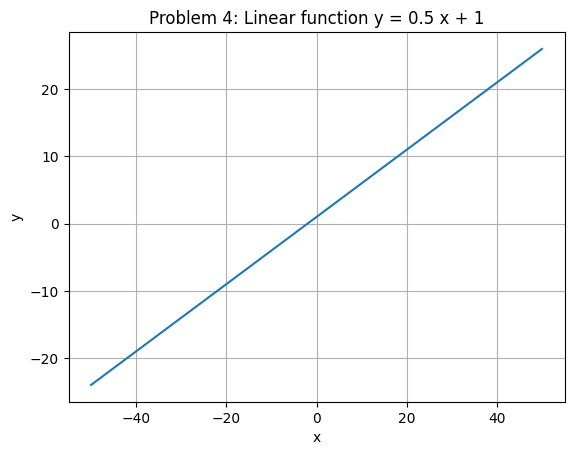

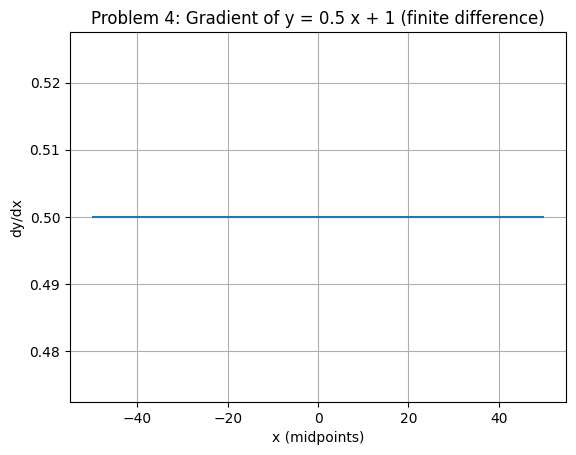

In [32]:
# [Problem 4] Draw a graph 

x_mid = (x[:-1] + x[1:]) / 2.0

# Plot the linear function y vs x
plot y vs x
plt.figure()
plt.plot(x, y)
plt.title("Problem 4: Linear function y = 0.5 x + 1")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Plot the gradient vs x_mid
plt.figure()
plt.plot(x_mid, gradient)
plt.title("Problem 4: Gradient of y = 0.5 x + 1 (finite difference)")
plt.xlabel("x (midpoints)")
plt.ylabel("dy/dx")
plt.grid(True)
plt.show()

Problem 5
y = x^2 -> x shape: (1001,) y shape: (1001,) grad shape: (1000,)
y = 2x^2+2x -> shapes: (1001,) (1001,) (1000,)
y = sin(x/2) -> shapes: (501,) (501,) (500,)



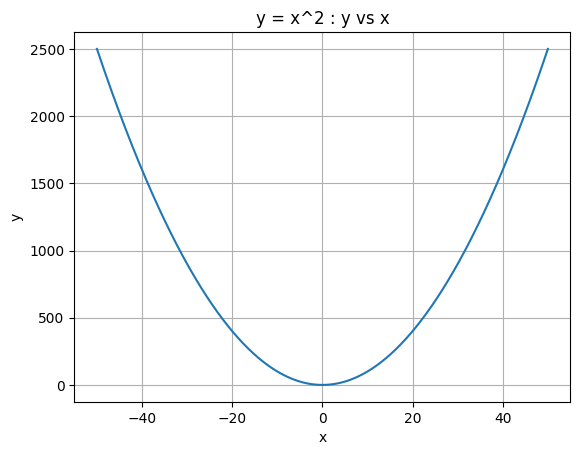

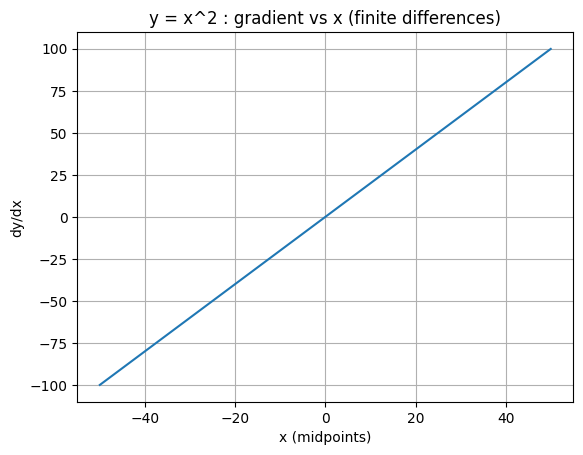

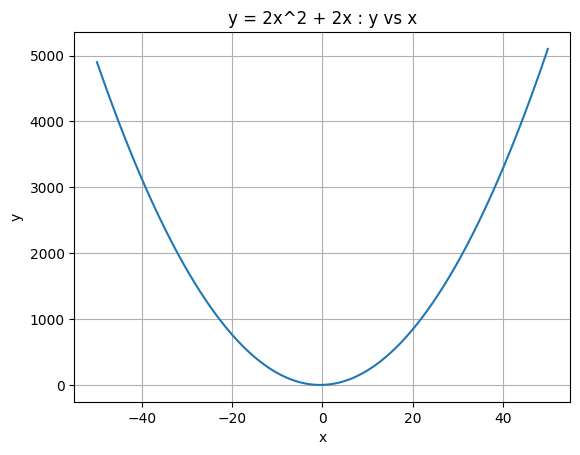

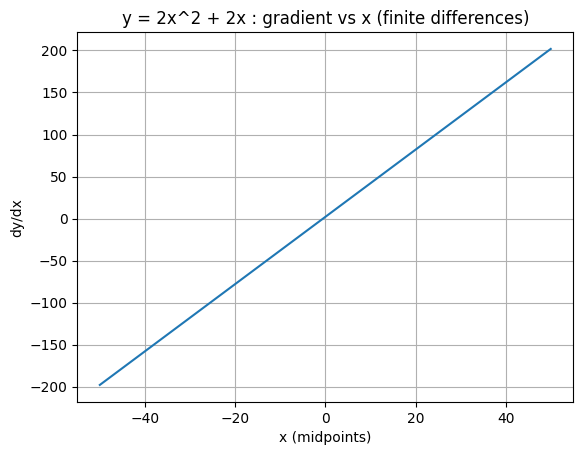

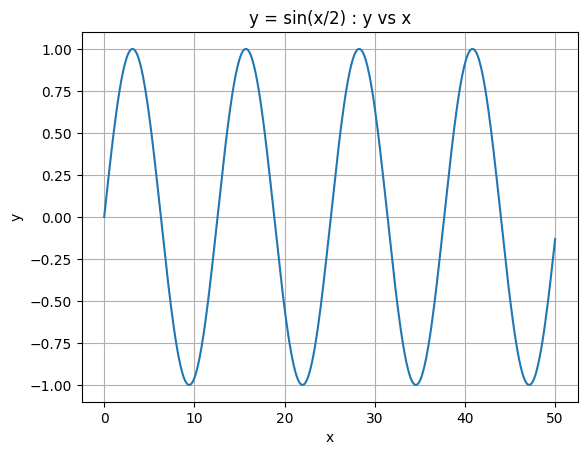

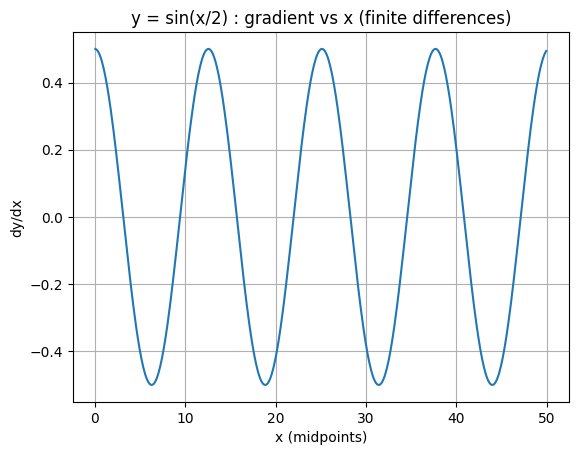

First 10 gradients for y = x^2: [-99.9 -99.7 -99.5 -99.3 -99.1 -98.9 -98.7 -98.5 -98.3 -98.1]
First 10 gradients for y = 2x^2 + 2x: [-197.8 -197.4 -197.  -196.6 -196.2 -195.8 -195.4 -195.  -194.6 -194.2]
First 10 gradients for y = sin(x/2): [0.49979169 0.49854247 0.49604716 0.49231198 0.48734628 0.48116247
 0.47377601 0.46520535 0.45547192 0.44460004]



In [33]:
# [Problem 5] Python functionalization
def compute_gradient(function, x_range=(-50, 50.1, 0.1)):
    """
    Compute x, y and finite-difference gradient for a function.

    Parameters:
      function : callable
          receives ndarray x and returns ndarray y (same shape)
      x_range : tuple (start, stop_exclusive, step)
          same semantics as np.arange(start, stop, step). Default uses 50.1 so 50.0 included.

    Returns:
      array_xy : ndarray shape (n, 2)  -> columns [x, y]
      gradient : ndarray shape (n-1,)  -> finite-difference dy/dx
      x, y : ndarrays returned for convenience
    """
    start, stop, step = x_range
    x_local = np.arange(start, stop, step)
    y_local = function(x_local)
    array_xy_local = np.column_stack((x_local, y_local))
    gradient_local = np.diff(y_local) / np.diff(x_local)
    return array_xy_local, gradient_local, x_local, y_local

# define functions
def f1(x):           # y = x^2
    return x**2

def f2(x):           # y = 2x^2 + 2x
    return 2*x**2 + 2*x

def f3(x):           # y = sin(x/2)
    return np.sin(x / 2.0)

# compute using compute_gradient
xy1, g1, x1, y1 = compute_gradient(f1, (-50, 50.1, 0.1))
xy2, g2, x2, y2 = compute_gradient(f2, (-50, 50.1, 0.1))
xy3, g3, x3, y3 = compute_gradient(f3, (0, 50.1, 0.1))   # 0 ≤ x ≤ 50

# quick prints
print("Problem 5")
print("y = x^2 -> x shape:", x1.shape, "y shape:", y1.shape, "grad shape:", g1.shape)
print("y = 2x^2+2x -> shapes:", x2.shape, y2.shape, g2.shape)
print("y = sin(x/2) -> shapes:", x3.shape, y3.shape, g3.shape)
print()

# Plot each function and its gradient (use a small helper)
def plot_function_and_gradient(x, y, g, label):
    x_mid = (x[:-1] + x[1:]) / 2.0
    plt.figure()
    plt.plot(x, y)
    plt.title(f"{label} : y vs x")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(x_mid, g)
    plt.title(f"{label} : gradient vs x (finite differences)")
    plt.xlabel("x (midpoints)")
    plt.ylabel("dy/dx")
    plt.grid(True)
    plt.show()

plot_function_and_gradient(x1, y1, g1, "y = x^2")
plot_function_and_gradient(x2, y2, g2, "y = 2x^2 + 2x")
plot_function_and_gradient(x3, y3, g3, "y = sin(x/2)")

# Also show the gradient arrays (first 10 entries) so you can inspect numerically:
print("First 10 gradients for y = x^2:", g1[:10])
print("First 10 gradients for y = 2x^2 + 2x:", g2[:10])
print("First 10 gradients for y = sin(x/2):", g3[:10])
print()


In [36]:
# [Problem 6] Find the minimum value
def report_minimum(x, y, g, label):
    idx_min = int(np.argmin(y))   # index where y is minimum
    x_at_min = x[idx_min]
    y_at_min = y[idx_min]

    # gradient array g corresponds to intervals between x points:
    # g[i] is slope approx between x[i] and x[i+1]
    slope_before = None
    slope_after = None
    if idx_min - 1 >= 0 and (idx_min - 1) < len(g):
        slope_before = float(g[idx_min - 1])
    if idx_min < len(g):
        slope_after = float(g[idx_min])

    print(f"[{label}] min y = {y_at_min} at x = {x_at_min} (index {idx_min})")
    print(f"[{label}] slope before min (approx): {slope_before}")
    print(f"[{label}] slope after  min (approx): {slope_after}")
    print()

print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
report_minimum(x1, y1, g1, "y = x^2")
report_minimum(x2, y2, g2, "y = 2x^2 + 2x")
report_minimum(x3, y3, g3, "y = sin(x/2)")

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[y = x^2] min y = 5.048709793414476e-25 at x = 7.105427357601002e-13 (index 500)
[y = x^2] slope before min (approx): -0.09999999999858034
[y = x^2] slope after  min (approx): 0.1000000000014225

[y = 2x^2 + 2x] min y = -0.5 at x = -0.49999999999929656 (index 495)
[y = 2x^2 + 2x] slope before min (approx): -0.1999999999971896
[y = 2x^2 + 2x] slope after  min (approx): 0.20000000000281676

[y = sin(x/2)] min y = -0.9999902065507035 at x = 22.0 (index 220)
[y = sin(x/2)] slope before min (approx): -0.010285346568865924
[y = sin(x/2)] slope after  min (approx): 0.014709200746580789

